In [1]:
import pandas as pd

df = pd.read_csv("titanic.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
print(df.shape)

df.info()

(891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [3]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


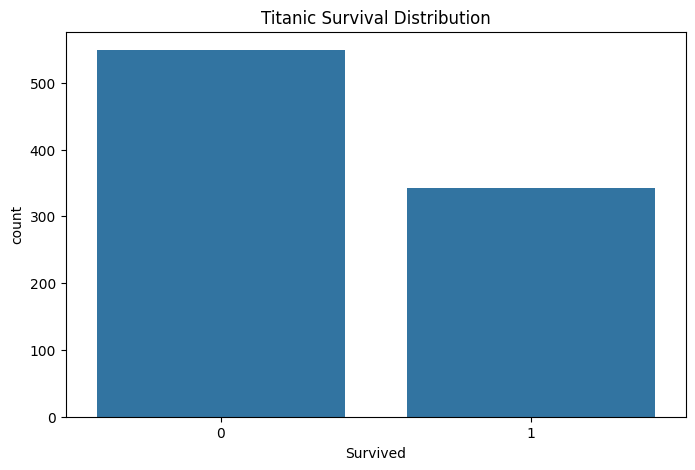

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(x=df["Survived"])

plt.title("Titanic Survival Distribution")

plt.show()

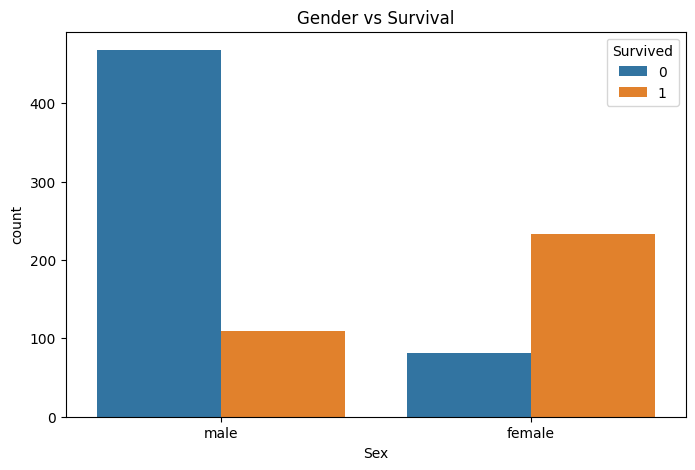

In [5]:
plt.figure(figsize=(8,5))

sns.countplot(
    x=df["Sex"],
    hue=df["Survived"]
)

plt.title("Gender vs Survival")

plt.show()

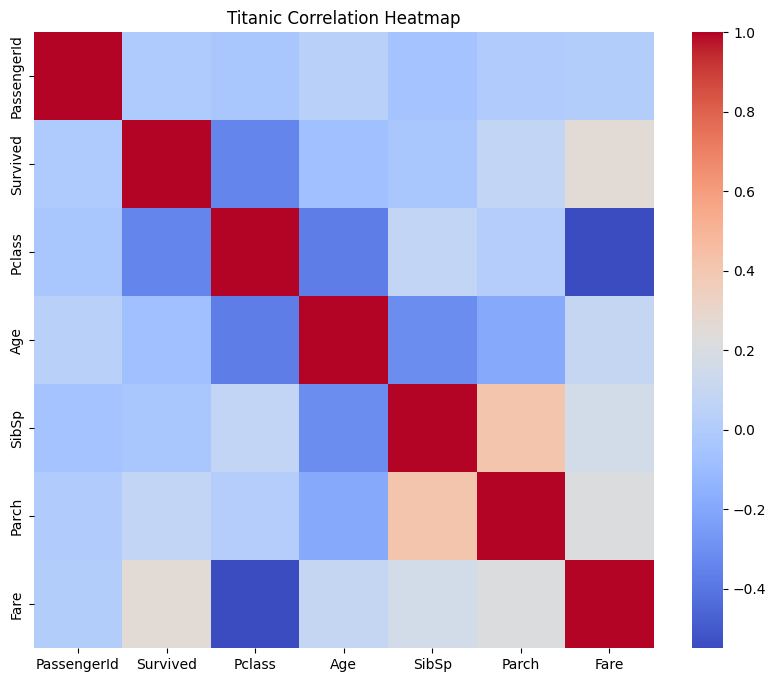

In [6]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    cmap="coolwarm"
)

plt.title("Titanic Correlation Heatmap")

plt.show()

In [7]:
df["Age"] = df["Age"].fillna(
    df["Age"].median()
)

df["Embarked"] = df["Embarked"].fillna(
    df["Embarked"].mode()[0]
)

df["Sex"] = df["Sex"].map({
    "male":0,
    "female":1
})

df["Embarked"] = df["Embarked"].map({
    "S":0,
    "C":1,
    "Q":2
})

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked"
]

X = df[features]

y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier()

model.fit(X_train, y_train)

predictions = model.predict(X_test)

accuracy = accuracy_score(
    y_test,
    predictions
)

print("Accuracy:", round(accuracy*100,2), "%")

Accuracy: 81.01 %


In [9]:
sample_passenger = [
    [1,1,25,0,0,100,1]
]

prediction = model.predict(
    sample_passenger
)

print("🚢 TITANIC SURVIVAL PREDICTOR")
print("---------------------------")

if prediction[0] == 1:
    print("Prediction: SURVIVED")
    print("Chance: High")
else:
    print("Prediction: NOT SURVIVED")
    print("Chance: Low")

🚢 TITANIC SURVIVAL PREDICTOR
---------------------------
Prediction: SURVIVED
Chance: High


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
